In [49]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv(r"C:\Users\Ong Hui Ling\Dropbox\PC\Documents\Github\Aspect-Based-Sentiment-Analysis\Dataset\PowerBI_input\RestaurantMetadata.csv")

# Check for null value

In [51]:
# check null count
df.isnull().sum()

place_id                      0
name                          0
address                       0
latitude                      0
longitude                     0
priceRange                 1264
place_overall_rating          0
userRatingCount               0
extract_date                  0
timestamp                     0
sub_category                  0
state                         0
operating_hours_cleaned       0
Monday_hours                  0
Tuesday_hours                 0
Wednesday_hours               0
Thursday_hours                0
Friday_hours                  0
Saturday_hours                0
Sunday_hours                  0
clean_name                    0
dtype: int64

In [52]:
df['priceRange'].value_counts()

priceRange
2.0    2134
1.0     285
3.0     168
4.0      15
Name: count, dtype: int64

# Test 1: Is priceRange affect restaurant overall rating?

In [53]:
not_null_restaurant = df[~df['priceRange'].isnull()]
not_null_restaurant = not_null_restaurant.drop_duplicates(subset='place_id')

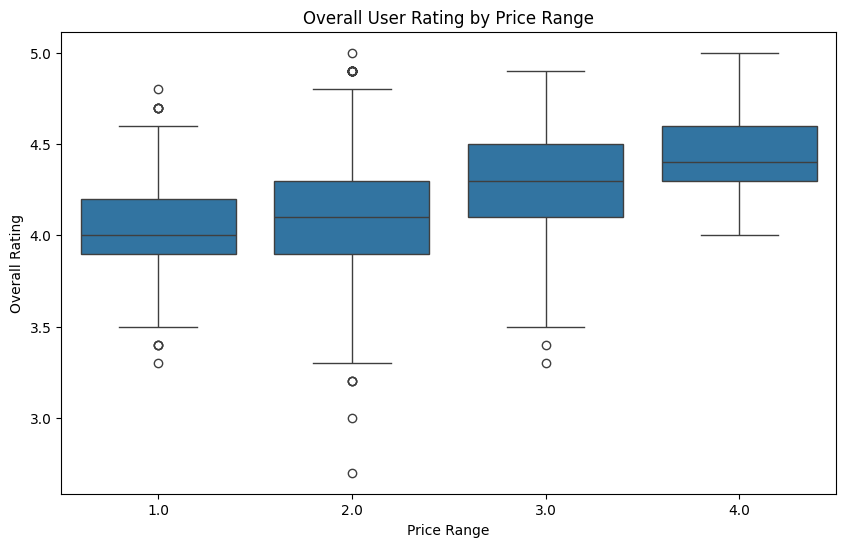

In [54]:
# ---  Create Box Plot for 'place_overall_rating' ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='priceRange', y='place_overall_rating', data=not_null_restaurant)
plt.title('Overall User Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Overall Rating')
plt.show()

## STAGE 1a: Normality Check: Is `place_overall_rating` Normally Distributed?

Before choosing a test (parametric ANOVA vs. non-parametric Kruskal-Wallis), we must verify normality.

**Methods used:**
1. **Histogram + KDE** — visual inspection of distribution shape
2. **Q-Q Plot** — checks if data follows a theoretical normal line
3. **Shapiro-Wilk Test** — formal normality test (best for n < 5,000); if n is large, we use **Kolmogorov-Smirnov**

Sample size: 2,602


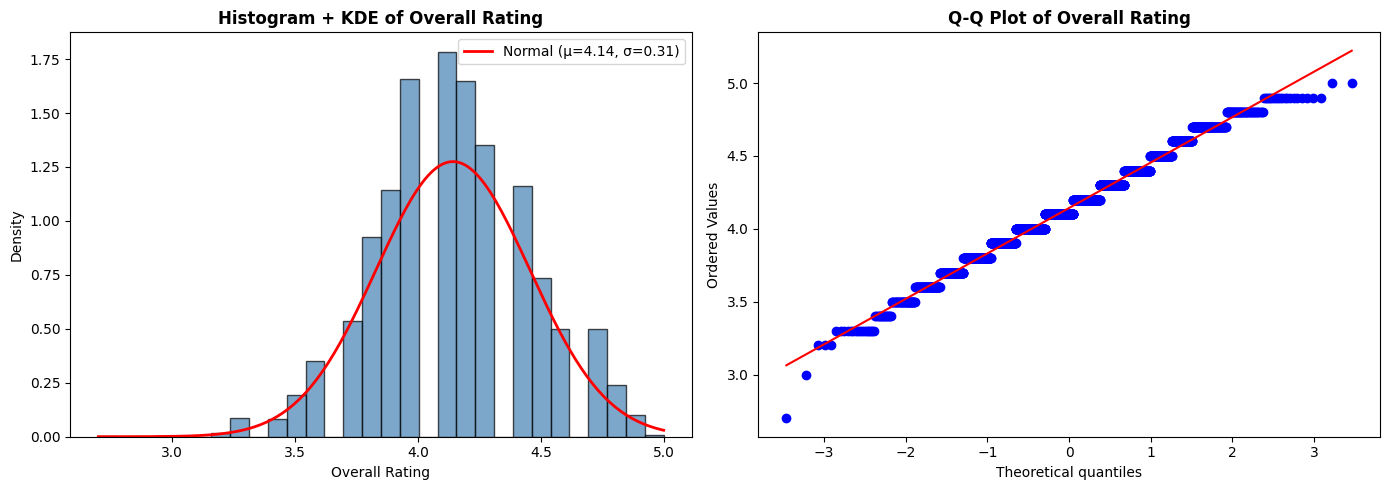


NORMALITY TEST RESULTS
Test used:   Shapiro-Wilk (n=2,602)
Statistic:   0.9887
p-value:     0.0000

❌ NOT normally distributed (p ≤ 0.05)
→ Use NON-PARAMETRIC test: Kruskal-Wallis H-test


In [55]:
from scipy.stats import shapiro, kstest, norm
import scipy.stats as stats

ratings = not_null_restaurant['place_overall_rating'].dropna()
n = len(ratings)
print(f"Sample size: {n:,}")

# ── 1. Histogram + KDE ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings, bins=30, edgecolor='black', color='steelblue', density=True, alpha=0.7)
axes[0].set_title('Histogram + KDE of Overall Rating', fontweight='bold')
axes[0].set_xlabel('Overall Rating')
axes[0].set_ylabel('Density')

# Overlay normal curve for reference
mu, std = ratings.mean(), ratings.std()
x = np.linspace(ratings.min(), ratings.max(), 200)
axes[0].plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2, label=f'Normal (μ={mu:.2f}, σ={std:.2f})')
axes[0].legend()

# ── 2. Q-Q Plot ─────────────────────────────────────────────────────────────
stats.probplot(ratings, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Overall Rating', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 3. Formal Normality Test ─────────────────────────────────────────────────
print("\n" + "="*60)
print("NORMALITY TEST RESULTS")
print("="*60)

if n <= 5000:
    stat, p = shapiro(ratings)
    test_name = "Shapiro-Wilk"
else:
    # Shapiro-Wilk is unreliable for large n; use K-S test instead
    stat, p = kstest(ratings, 'norm', args=(mu, std))
    test_name = "Kolmogorov-Smirnov"

print(f"Test used:   {test_name} (n={n:,})")
print(f"Statistic:   {stat:.4f}")
print(f"p-value:     {p:.4f}")
print()
if p > 0.05:
    print("✅ NORMAL distribution (p > 0.05)")
    print("→ Use PARAMETRIC test: One-Way ANOVA")
else:
    print("❌ NOT normally distributed (p ≤ 0.05)")
    print("→ Use NON-PARAMETRIC test: Kruskal-Wallis H-test")


## STAGE 1b: Homogeneity of Variance Check: Is variance in `place_overall_rating` equal across price ranges?

Even though the data is non-normal (making ANOVA inappropriate), we still check **homogeneity of variance** for academic completeness and to characterise the data structure.

**Test Selected: Levene's Test**
- Preferred over Bartlett's Test because it is **robust to non-normality** — it uses deviations from group medians rather than assuming a normal distribution.
- A significant result (p ≤ 0.05) indicates **heteroscedasticity** (unequal variances across groups), which is an additional violation of ANOVA assumptions and further justifies the Kruskal-Wallis approach.

- **H₀:** Variances are equal across all price range groups (homoscedastic).
- **H₁:** At least one group has a significantly different variance (heteroscedastic).


In [56]:
from scipy.stats import levene

# ── Levene's Test for Homogeneity of Variance ─────────────────────────────────
# Groups: one array of ratings per price category
levene_stat, p_levene = levene(*rating_groups)

print(f"{'='*60}")
print("LEVENE'S TEST: Homogeneity of Variance")
print(f"  Variable: place_overall_rating  |  Groups: priceRange")
print(f"{'='*60}")
print(f"Levene statistic: {levene_stat:.4f}")
print(f"p-value:          {p_levene:.4f}")
print()
if p_levene > 0.05:
    print("✅ HOMOSCEDASTIC (p > 0.05): Variances are equal across groups.")
    print("   → Variance assumption of ANOVA is met (though normality is still violated).")
else:
    print("❌ HETEROSCEDASTIC (p ≤ 0.05): Variances are NOT equal across groups.")
    print("   → This is an additional violation of ANOVA assumptions.")
    print("   → Kruskal-Wallis is doubly justified (non-normal AND unequal variances).")

# ── Variance summary per group ─────────────────────────────────────────────────
print(f"\nVariance per price range group:")
for cat, grp in zip(price_categories, rating_groups):
    print(f"  {cat}: var = {grp.var():.4f},  std = {grp.std():.4f},  n = {len(grp)}")


LEVENE'S TEST: Homogeneity of Variance
  Variable: place_overall_rating  |  Groups: priceRange
Levene statistic: 5.7856
p-value:          0.0006

❌ HETEROSCEDASTIC (p ≤ 0.05): Variances are NOT equal across groups.
   → This is an additional violation of ANOVA assumptions.
   → Kruskal-Wallis is doubly justified (non-normal AND unequal variances).

Variance per price range group:
  1.0: var = 0.0681,  std = 0.2609,  n = 285
  2.0: var = 0.1006,  std = 0.3172,  n = 2134
  3.0: var = 0.0727,  std = 0.2697,  n = 168
  4.0: var = 0.0626,  std = 0.2501,  n = 15


## STAGE 2: Hypothesis Test: Does Price Range Affect Overall Restaurant Rating?

Since `place_overall_rating` is **not normally distributed** (Shapiro-Wilk p ≤ 0.05) , we use the **Kruskal-Wallis H-test** — the non-parametric equivalent of One-Way ANOVA.

- **H₀ (Null):** There is no significant difference in overall rating across price ranges.
- **H₁ (Alternative):** At least one price range group has a significantly different overall rating.

If significant (p ≤ 0.05), we follow up with **Dunn's post-hoc test** (with Bonferroni correction) to identify *which* price range pairs differ.

Groups:
  1.0: n=285, median=4.00, mean=4.05
  2.0: n=2134, median=4.10, mean=4.14
  3.0: n=168, median=4.30, mean=4.30
  4.0: n=15, median=4.40, mean=4.46

KRUSKAL-WALLIS TEST: Price Range vs. Overall Rating
H-statistic: 89.8017
p-value:     0.0000

✅ SIGNIFICANT (p ≤ 0.05)
→ Price range DOES significantly affect overall rating.
→ Proceeding to Dunn's post-hoc test to identify which pairs differ...

DUNN'S POST-HOC TEST (Bonferroni corrected p-values)
     1.0     2.0     3.0     4.0
1.0  1.0  0.0000  0.0000  0.0000
2.0  0.0  1.0000  0.0000  0.0006
3.0  0.0  0.0000  1.0000  0.5304
4.0  0.0  0.0006  0.5304  1.0000


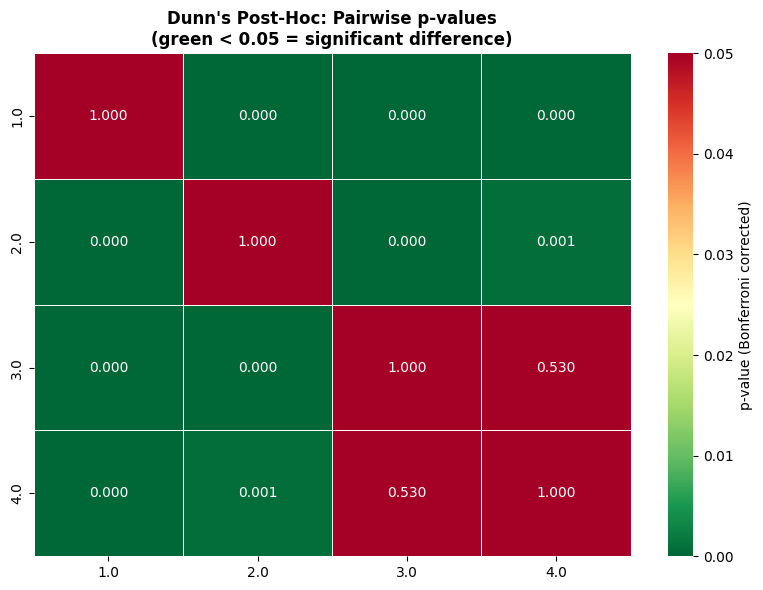


Significant pairwise differences (p ≤ 0.05):
  1.0 vs 2.0: p = 0.0000 ✅
  1.0 vs 3.0: p = 0.0000 ✅
  1.0 vs 4.0: p = 0.0000 ✅
  2.0 vs 3.0: p = 0.0000 ✅
  2.0 vs 4.0: p = 0.0006 ✅


In [57]:
from scipy.stats import kruskal

# ── 1. Prepare groups ────────────────────────────────────────────────────────
price_categories = sorted(not_null_restaurant['priceRange'].dropna().unique())
rating_groups = [
    not_null_restaurant[not_null_restaurant['priceRange'] == cat]['place_overall_rating'].dropna()
    for cat in price_categories
]

print("Groups:")
for cat, grp in zip(price_categories, rating_groups):
    print(f"  {cat}: n={len(grp)}, median={grp.median():.2f}, mean={grp.mean():.2f}")

# ── 2. Kruskal-Wallis H-test ─────────────────────────────────────────────────
h_stat, p_value = kruskal(*rating_groups)

print(f"\n{'='*60}")
print("KRUSKAL-WALLIS TEST: Price Range vs. Overall Rating")
print(f"{'='*60}")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    print("✅ SIGNIFICANT (p ≤ 0.05)")
    print("→ Price range DOES significantly affect overall rating.")
    print("→ Proceeding to Dunn's post-hoc test to identify which pairs differ...")
else:
    print("❌ NOT significant (p > 0.05)")
    print("→ Price range does NOT significantly affect overall rating.")

# ── 3. Dunn's Post-Hoc Test (only if significant) ───────────────────────────
if p_value < 0.05:
    try:
        from scikit_posthocs import posthoc_dunn
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-posthocs", "-q"])
        from scikit_posthocs import posthoc_dunn

    dunn_result = posthoc_dunn(
        not_null_restaurant[['priceRange', 'place_overall_rating']].dropna(),
        val_col='place_overall_rating',
        group_col='priceRange',
        p_adjust='bonferroni'
    )

    print(f"\n{'='*60}")
    print("DUNN'S POST-HOC TEST (Bonferroni corrected p-values)")
    print(f"{'='*60}")
    print(dunn_result.round(4))

    # Heatmap for easy reading
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        dunn_result, annot=True, fmt=".3f", cmap="RdYlGn_r",
        linewidths=0.5, vmin=0, vmax=0.05,
        cbar_kws={'label': 'p-value (Bonferroni corrected)'}
    )
    plt.title("Dunn's Post-Hoc: Pairwise p-values\n(green < 0.05 = significant difference)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary of significant pairs
    print("\nSignificant pairwise differences (p ≤ 0.05):")
    found = False
    cats = dunn_result.columns.tolist()
    for i in range(len(cats)):
        for j in range(i+1, len(cats)):
            p = dunn_result.iloc[i, j]
            if p <= 0.05:
                print(f"  {cats[i]} vs {cats[j]}: p = {p:.4f} ✅")
                found = True
    if not found:
        print("  None found after Bonferroni correction.")


**Findings:**
- Budget restaurants (1 and 2) are rated significantly lower than mid-high (3) and premium restaurants (4)
- There are no significant difference in overall ratings between mid-high and premium restaurants

# Test 2: Is priceRange affect User Rating Count

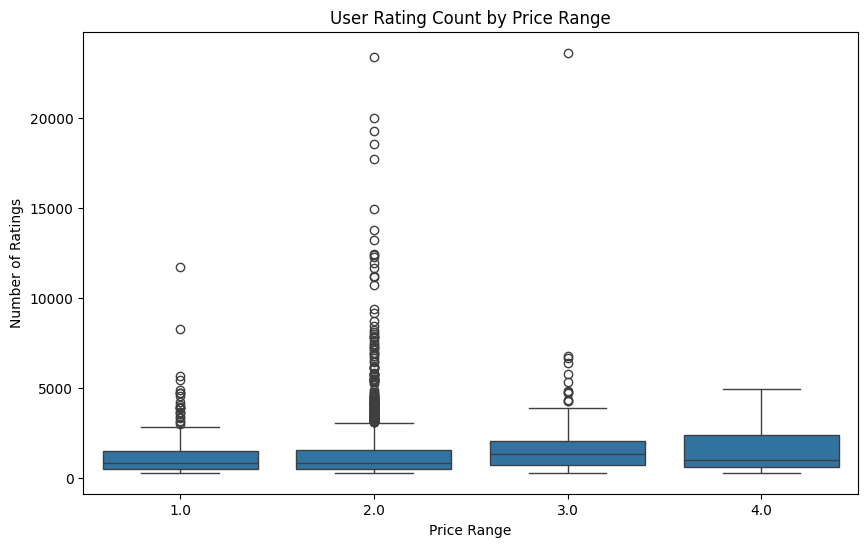

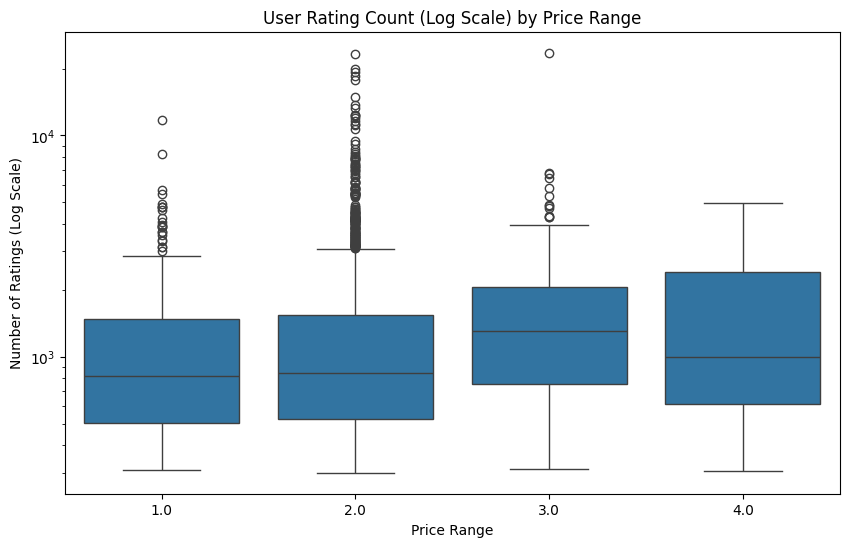

In [58]:
# ---  Create Box Plot for 'userRatingCount' ---
# Note: This might look skewed, which is why we test!
plt.figure(figsize=(10, 6))
sns.boxplot(x='priceRange', y='userRatingCount', data=not_null_restaurant)
plt.title('User Rating Count by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Number of Ratings')
plt.show() 

# For rating count, a log scale might be easier to see
plt.figure(figsize=(10, 6))
sns.boxplot(x='priceRange', y='userRatingCount', data=not_null_restaurant)
plt.yscale('log') # Set y-axis to log scale
plt.title('User Rating Count (Log Scale) by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Number of Ratings (Log Scale)')
plt.show()

## STAGE 1: Normality Check: Is `userRatingCount` Normally Distributed?

`userRatingCount` is **discrete count data** — the number of reviews a restaurant has received.  
Count data is almost always **right-skewed**: most restaurants have few reviews, while a small number of popular ones have thousands. We verify this formally before selecting a test.

Sample size: 2,602
Min: 300,  Max: 23,641,  Median: 863,  Mean: 1379


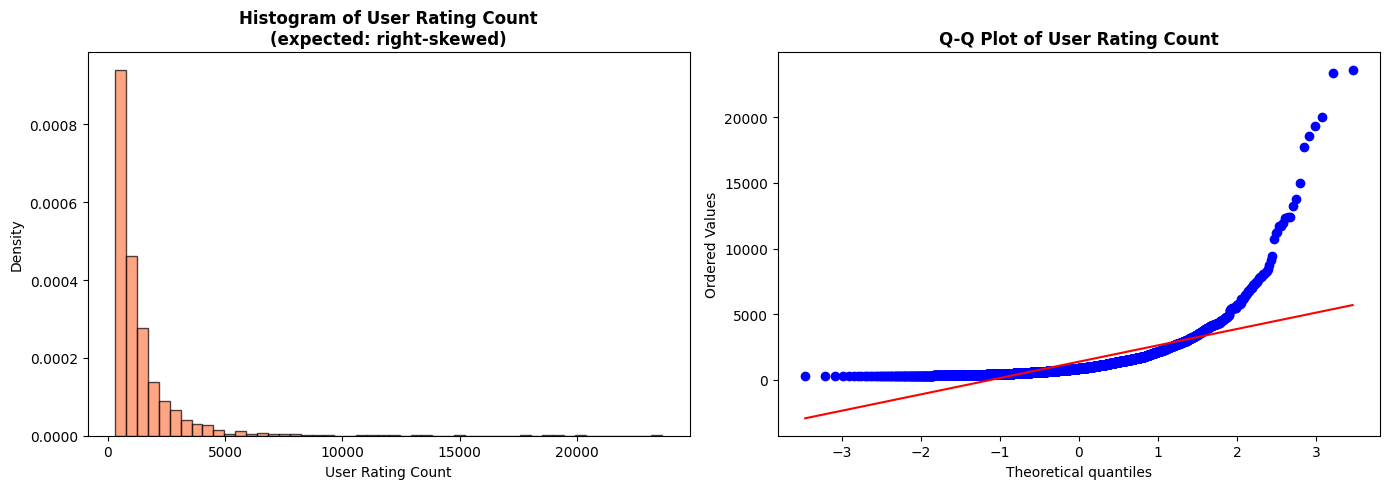


NORMALITY TEST RESULTS
Test used:   Shapiro-Wilk (n=2,602)
Statistic:   0.5387
p-value:     0.0000

❌ NOT normally distributed (p ≤ 0.05)
→ Count data is right-skewed as expected.
→ Use NON-PARAMETRIC test: Kruskal-Wallis H-test


In [59]:
counts = not_null_restaurant['userRatingCount'].dropna()
n = len(counts)
print(f"Sample size: {n:,}")
print(f"Min: {counts.min()},  Max: {counts.max():,},  Median: {counts.median():.0f},  Mean: {counts.mean():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. Histogram (raw + log scale overlay) ──────────────────────────────────
axes[0].hist(counts, bins=50, edgecolor='black', color='coral', density=True, alpha=0.7)
axes[0].set_title('Histogram of User Rating Count\n(expected: right-skewed)', fontweight='bold')
axes[0].set_xlabel('User Rating Count')
axes[0].set_ylabel('Density')

# ── 2. Q-Q Plot ─────────────────────────────────────────────────────────────
stats.probplot(counts, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of User Rating Count', fontweight='bold')

plt.tight_layout()
plt.show()

# ── 3. Formal Normality Test ─────────────────────────────────────────────────
print("\n" + "="*60)
print("NORMALITY TEST RESULTS")
print("="*60)

if n <= 5000:
    stat, p = shapiro(counts)
    test_name = "Shapiro-Wilk"
else:
    mu_c, std_c = counts.mean(), counts.std()
    stat, p = kstest(counts, 'norm', args=(mu_c, std_c))
    test_name = "Kolmogorov-Smirnov"

print(f"Test used:   {test_name} (n={n:,})")
print(f"Statistic:   {stat:.4f}")
print(f"p-value:     {p:.4f}")
print()
if p > 0.05:
    print("✅ NORMAL distribution (p > 0.05) — use ANOVA")
else:
    print("❌ NOT normally distributed (p ≤ 0.05)")
    print("→ Count data is right-skewed as expected.")
    print("→ Use NON-PARAMETRIC test: Kruskal-Wallis H-test")


## STAGE 1b: Homogeneity of Variance Check: Is variance in `userRatingCount` equal across price ranges?

Even though count data is non-normal, we check whether the spread (variance) of review counts differs across price tiers. This documents the full statistical profile of the variable.

**Test Selected: Levene's Test** (robust to non-normality)

- **H₀:** Variances in review count are equal across all price range groups.
- **H₁:** At least one group has a significantly different variance in review count.


In [60]:
from scipy.stats import levene

# ── Levene's Test for Homogeneity of Variance ─────────────────────────────────
# Groups must be defined here — count_groups is not yet available at this stage
_price_cats_lev_c = sorted(not_null_restaurant['priceRange'].dropna().unique())
_count_groups_lev = [
    not_null_restaurant[not_null_restaurant['priceRange'] == cat]['userRatingCount'].dropna()
    for cat in _price_cats_lev_c
]

levene_stat_c, p_levene_c = levene(*_count_groups_lev)

print(f"{'='*60}")
print("LEVENE'S TEST: Homogeneity of Variance")
print(f"  Variable: userRatingCount  |  Groups: priceRange")
print(f"{'='*60}")
print(f"Levene statistic: {levene_stat_c:.4f}")
print(f"p-value:          {p_levene_c:.4f}")
print()
if p_levene_c > 0.05:
    print("✅ HOMOSCEDASTIC (p > 0.05): Variances are equal across groups.")
else:
    print("❌ HETEROSCEDASTIC (p ≤ 0.05): Variances are NOT equal across groups.")
    print("   → Kruskal-Wallis is further justified (non-normal AND unequal variances).")

print(f"\nVariance per price range group:")
for cat, grp in zip(_price_cats_lev_c, _count_groups_lev):
    print(f"  {cat}: var = {grp.var():.1f},  std = {grp.std():.1f},  n = {len(grp)}")


LEVENE'S TEST: Homogeneity of Variance
  Variable: userRatingCount  |  Groups: priceRange
Levene statistic: 1.2225
p-value:          0.2999

✅ HOMOSCEDASTIC (p > 0.05): Variances are equal across groups.

Variance per price range group:
  1.0: var = 1608871.7,  std = 1268.4,  n = 285
  2.0: var = 2913916.4,  std = 1707.0,  n = 2134
  3.0: var = 4583684.2,  std = 2141.0,  n = 168
  4.0: var = 1930376.2,  std = 1389.4,  n = 15


## STAGE 2: Hypothesis Test: Does Price Range Affect User Rating Count?

Since `userRatingCount` is not normally distributed (right-skewed count data), we use **Kruskal-Wallis H-test**.

- **H₀ (Null):** There is no significant difference in review volume across price ranges.
- **H₁ (Alternative):** At least one price range group has a significantly different review volume.

If significant, Dunn's post-hoc test identifies which pairs differ.

Groups:
  1.0: n=285, median=819, mean=1244
  2.0: n=2134, median=844, mean=1365
  3.0: n=168, median=1315, mean=1767
  4.0: n=15, median=997, mean=1619

KRUSKAL-WALLIS TEST: Price Range vs. User Rating Count
H-statistic: 28.8102
p-value:     0.0000

✅ SIGNIFICANT (p ≤ 0.05)
→ Price range DOES significantly affect review volume.
→ Proceeding to Dunn's post-hoc test...

DUNN'S POST-HOC TEST (Bonferroni corrected p-values)
     1.0  2.0  3.0  4.0
1.0  1.0  1.0  0.0  1.0
2.0  1.0  1.0  0.0  1.0
3.0  0.0  0.0  1.0  1.0
4.0  1.0  1.0  1.0  1.0


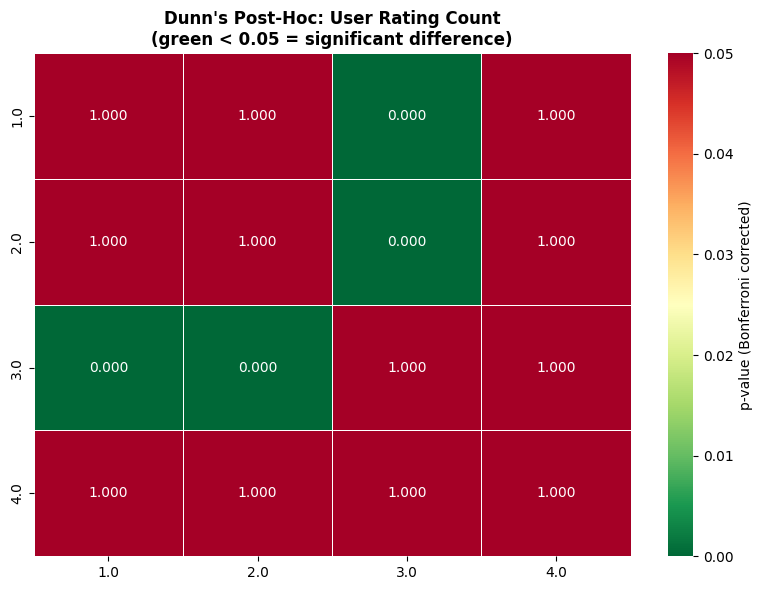


Significant pairwise differences (p ≤ 0.05):
  1.0 vs 3.0: p = 0.0000 ✅
  2.0 vs 3.0: p = 0.0000 ✅


In [61]:
count_groups = [
    not_null_restaurant[not_null_restaurant['priceRange'] == cat]['userRatingCount'].dropna()
    for cat in price_categories
]

print("Groups:")
for cat, grp in zip(price_categories, count_groups):
    print(f"  {cat}: n={len(grp)}, median={grp.median():.0f}, mean={grp.mean():.0f}")

# ── Kruskal-Wallis ────────────────────────────────────────────────────────────
h_stat, p_value_count = kruskal(*count_groups)

print(f"\n{'='*60}")
print("KRUSKAL-WALLIS TEST: Price Range vs. User Rating Count")
print(f"{'='*60}")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_value_count:.4f}")
print()
if p_value_count < 0.05:
    print("✅ SIGNIFICANT (p ≤ 0.05)")
    print("→ Price range DOES significantly affect review volume.")
    print("→ Proceeding to Dunn's post-hoc test...")
else:
    print("❌ NOT significant (p > 0.05)")
    print("→ Price range does NOT significantly affect review volume.")

# ── Dunn's Post-Hoc (only if significant) ────────────────────────────────────
if p_value_count < 0.05:
    dunn_count = posthoc_dunn(
        not_null_restaurant[['priceRange', 'userRatingCount']].dropna(),
        val_col='userRatingCount',
        group_col='priceRange',
        p_adjust='bonferroni'
    )

    print(f"\n{'='*60}")
    print("DUNN'S POST-HOC TEST (Bonferroni corrected p-values)")
    print(f"{'='*60}")
    print(dunn_count.round(4))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        dunn_count, annot=True, fmt=".3f", cmap="RdYlGn_r",
        linewidths=0.5, vmin=0, vmax=0.05,
        cbar_kws={'label': 'p-value (Bonferroni corrected)'}
    )
    plt.title("Dunn's Post-Hoc: User Rating Count\n(green < 0.05 = significant difference)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nSignificant pairwise differences (p ≤ 0.05):")
    found = False
    cats = dunn_count.columns.tolist()
    for i in range(len(cats)):
        for j in range(i+1, len(cats)):
            p = dunn_count.iloc[i, j]
            if p <= 0.05:
                print(f"  {cats[i]} vs {cats[j]}: p = {p:.4f} ✅")
                found = True
    if not found:
        print("  None found after Bonferroni correction.")


**Findings:**
- Mid-range ($$$ / 3.0) restaurants have a **significantly different review volume** compared to both budget ($) and moderate ($$) restaurants
- No significant difference was found between budget ($) and moderate ($$) — they attract a similar volume of reviews
- The $$$$ tier could not be meaningfully compared due to **very small sample size (n=15)**, limiting statistical power

**Interpretation:** The $$$ segment stands out as an anomaly in review engagement. This may reflect that mid-to-high-range restaurants attract a more opinionated diner segment who are more likely to leave reviews, or that they occupy a niche market with a distinct reviewer base compared to everyday budget and moderate eateries.

# Test 3: Is priceRange affect Weighted Sentiment Score

In [62]:
df_macro_sentiments = pd.read_csv(r"C:\Users\Ong Hui Ling\Dropbox\PC\Documents\Github\Aspect-Based-Sentiment-Analysis\Dataset\PowerBI_input\MacroSentiments.csv")
df_merged = pd.merge(df, df_macro_sentiments, on="place_id", how="outer")

In [63]:
df_merged = df_merged[(~df_merged['Original_Review_ID'].isna()) & (df_merged['aspect']!='GENERAL')]

In [64]:
# ── Compute Weighted Sentiment Score (WSS) per restaurant ────────────────────
# Formula: WSS = sum(confidence * direction) / n_segments
# direction: +1 for positive, -1 for negative
# Result is in [-1, +1]: positive = net positive sentiment, negative = net negative

df_merged['direction'] = df_merged['predicted_sentiment'].map({'positive': 1, 'negative': -1})
df_merged['weighted_contribution'] = df_merged['confidence'] * df_merged['direction']

wss_per_restaurant = (
    df_merged.groupby('place_id')
    .agg(
        WSS=('weighted_contribution', 'sum'),
        n_segments=('weighted_contribution', 'count'),
        priceRange=('priceRange', 'first')
    )
    .reset_index()
)

# Normalise by segment count so restaurants with more reviews are not penalised
wss_per_restaurant['WSS_normalized'] = wss_per_restaurant['WSS'] / wss_per_restaurant['n_segments']

# Drop rows with no price range
wss_pr = wss_per_restaurant[~wss_per_restaurant['priceRange'].isna()].copy()

print(f"Restaurants with price range data: {len(wss_pr):,}")
print(f"\nWSS summary by price range:")
print(wss_pr.groupby('priceRange')['WSS_normalized'].describe().round(3))


Restaurants with price range data: 2,601

WSS summary by price range:
             count   mean    std    min    25%    50%    75%    max
priceRange                                                         
1.0          285.0  0.784  0.219 -0.428  0.749  0.869  0.914  0.974
2.0         2133.0  0.737  0.308 -0.962  0.692  0.866  0.922  0.986
3.0          168.0  0.848  0.181 -0.624  0.833  0.910  0.939  0.978
4.0           15.0  0.764  0.291  0.133  0.707  0.933  0.941  0.968


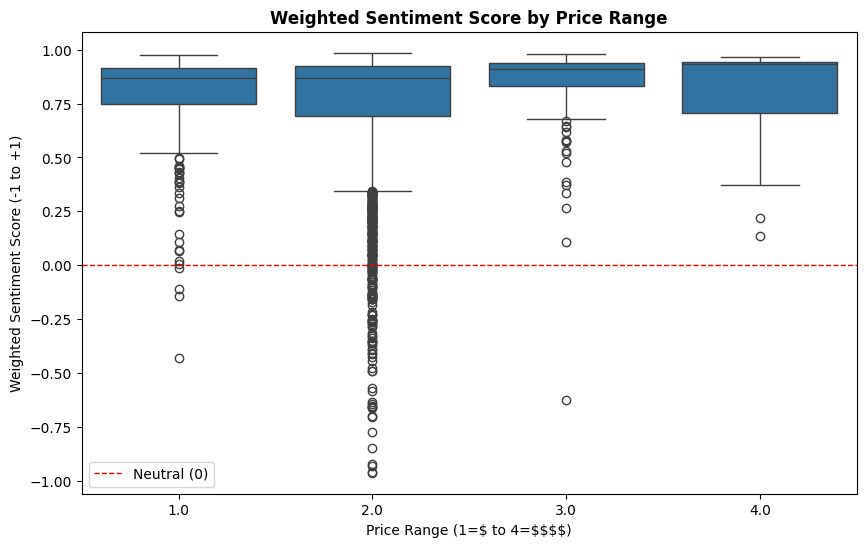

In [65]:
# ── Box Plot: WSS by Price Range ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.boxplot(x='priceRange', y='WSS_normalized', data=wss_pr)
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')
plt.title('Weighted Sentiment Score by Price Range', fontweight='bold')
plt.xlabel('Price Range (1=$ to 4=$$$$)')
plt.ylabel('Weighted Sentiment Score (-1 to +1)')
plt.legend()
plt.show()


## STAGE 1a: Normality Check on Weighted Sentiment Score

Sample size: 2,601


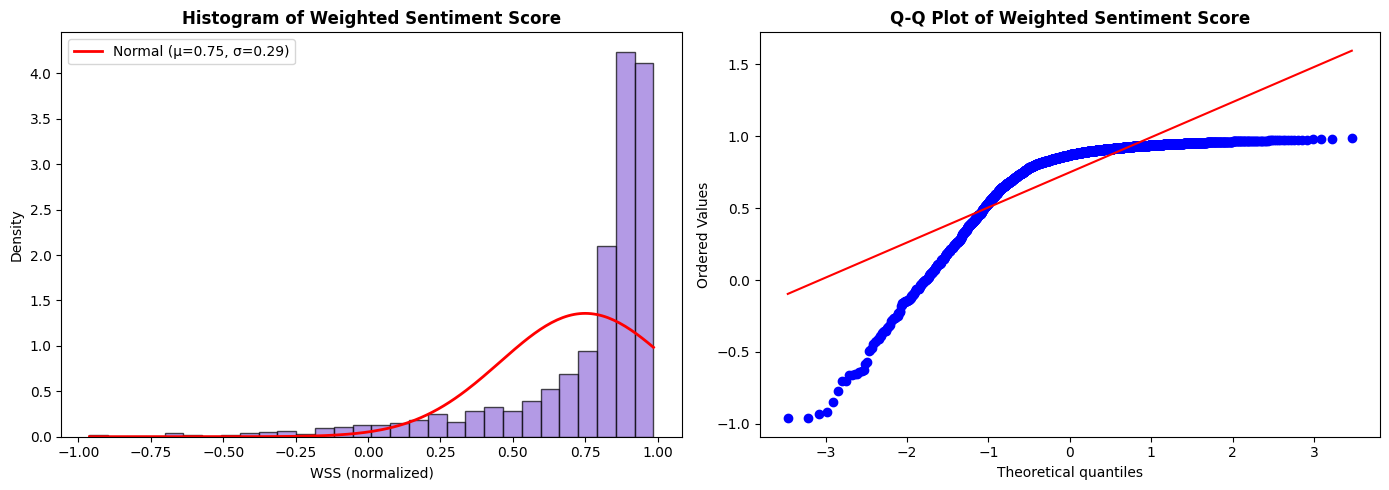


NORMALITY TEST RESULTS
Test used:   Shapiro-Wilk (n=2,601)
Statistic:   0.6901
p-value:     0.0000

❌ NOT normal — use Kruskal-Wallis H-test


In [69]:
from scipy.stats import levene

wss_values = wss_pr['WSS_normalized'].dropna()
n = len(wss_values)
print(f"Sample size: {n:,}")

# ── Normality Check ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mu_w, std_w = wss_values.mean(), wss_values.std()
axes[0].hist(wss_values, bins=30, edgecolor='black', color='mediumpurple', density=True, alpha=0.7)
x = np.linspace(wss_values.min(), wss_values.max(), 200)
axes[0].plot(x, norm.pdf(x, mu_w, std_w), 'r-', linewidth=2, label=f'Normal (μ={mu_w:.2f}, σ={std_w:.2f})')
axes[0].set_title('Histogram of Weighted Sentiment Score', fontweight='bold')
axes[0].set_xlabel('WSS (normalized)')
axes[0].set_ylabel('Density')
axes[0].legend()

stats.probplot(wss_values, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Weighted Sentiment Score', fontweight='bold')

plt.tight_layout()
plt.show()

if n <= 5000:
    stat, p_norm = shapiro(wss_values)
    test_name = "Shapiro-Wilk"
else:
    stat, p_norm = kstest(wss_values, 'norm', args=(mu_w, std_w))
    test_name = "Kolmogorov-Smirnov"

print(f"\n{'='*60}")
print("NORMALITY TEST RESULTS")
print(f"{'='*60}")
print(f"Test used:   {test_name} (n={n:,})")
print(f"Statistic:   {stat:.4f}")
print(f"p-value:     {p_norm:.4f}")
print()
if p_norm > 0.05:
    print("✅ NORMAL — use One-Way ANOVA")
else:
    print("❌ NOT normal — use Kruskal-Wallis H-test")

## STAGE 1b: Homogeneity of Variance — Levene's Test

**Levene's Test** is robust to non-normality and checks whether the variance (spread) of WSS is consistent across price range groups.

- **H₀:** All price range groups have equal variance in weighted sentiment score.
- **H₁:** At least one group has a statistically different variance.

> Note: Kruskal-Wallis does not strictly require homoscedasticity, but unequal variances can affect interpretation of post-hoc pairwise comparisons.

In [70]:
# ── Levene's Test (Homogeneity of Variance) ───────────────────────────────────
_wss_price_cats_lev = sorted(wss_pr['priceRange'].unique())
_wss_groups_lev = [
    wss_pr[wss_pr['priceRange'] == cat]['WSS_normalized'].dropna()
    for cat in _wss_price_cats_lev
]

lev_stat_wss, lev_p_wss = levene(*_wss_groups_lev)

print(f"\n{'='*60}")
print("LEVENE'S TEST: Homogeneity of Variance — Weighted Sentiment Score")
print(f"{'='*60}")
for cat, grp in zip(_wss_price_cats_lev, _wss_groups_lev):
    print(f"  Price Range {cat}: n={len(grp)}, variance={grp.var():.5f}")

print(f"\nLevene's statistic: {lev_stat_wss:.4f}")
print(f"p-value:            {lev_p_wss:.4f}")
print()
if lev_p_wss > 0.05:
    print("✅ EQUAL VARIANCES (p > 0.05)")
    print("→ Group variances are homogeneous.")
else:
    print("❌ UNEQUAL VARIANCES (p ≤ 0.05)")
    print("→ At least one group has a different spread in WSS.")
    print("→ Kruskal-Wallis remains valid; note heteroscedasticity in interpretation.")


LEVENE'S TEST: Homogeneity of Variance — Weighted Sentiment Score
  Price Range 1.0: n=285, variance=0.04789
  Price Range 2.0: n=2133, variance=0.09463
  Price Range 3.0: n=168, variance=0.03292
  Price Range 4.0: n=15, variance=0.08490

Levene's statistic: 9.0297
p-value:            0.0000

❌ UNEQUAL VARIANCES (p ≤ 0.05)
→ At least one group has a different spread in WSS.
→ Kruskal-Wallis remains valid; note heteroscedasticity in interpretation.


## STAGE 2: Hypothesis Test: Does Price Range Affect Weighted Sentiment Score?

- **H₀ (Null):** There is no significant difference in sentiment score across price ranges.
- **H₁ (Alternative):** At least one price range group has a significantly different sentiment score.



Groups:
  1.0: n=285, median=0.869, mean=0.784
  2.0: n=2133, median=0.866, mean=0.737
  3.0: n=168, median=0.910, mean=0.848
  4.0: n=15, median=0.933, mean=0.764

KRUSKAL-WALLIS TEST: Price Range vs. Weighted Sentiment Score
H-statistic: 33.0387
p-value:     0.0000

✅ SIGNIFICANT (p ≤ 0.05)
→ Price range DOES significantly affect sentiment score.
→ Proceeding to Dunn's post-hoc test...

DUNN'S POST-HOC TEST (Bonferroni corrected p-values)
     1.0     2.0  3.0     4.0
1.0  1.0  1.0000  0.0  1.0000
2.0  1.0  1.0000  0.0  0.9636
3.0  0.0  0.0000  1.0  1.0000
4.0  1.0  0.9636  1.0  1.0000


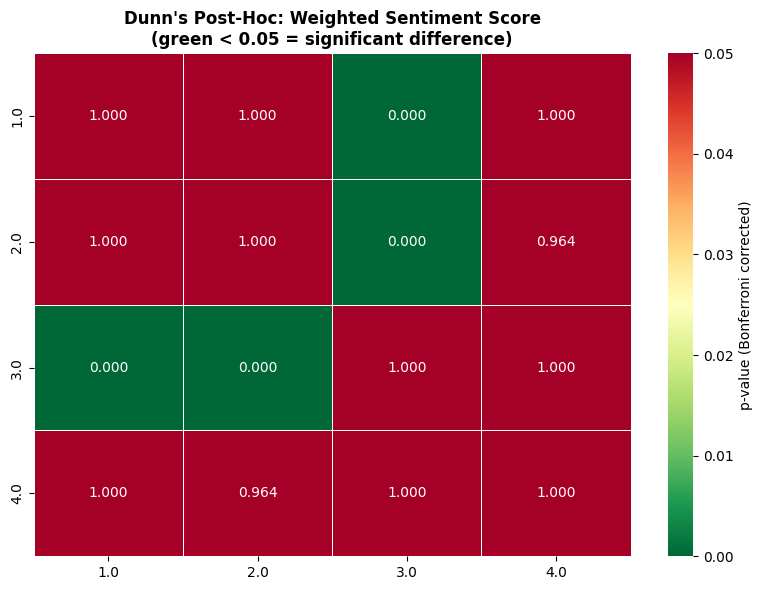


Significant pairwise differences (p ≤ 0.05):
  1.0 vs 3.0: p = 0.0000 ✅
  2.0 vs 3.0: p = 0.0000 ✅


In [71]:
# ── Kruskal-Wallis ────────────────────────────────────────────────────────────
wss_price_cats = sorted(wss_pr['priceRange'].unique())
wss_groups = [
    wss_pr[wss_pr['priceRange'] == cat]['WSS_normalized'].dropna()
    for cat in wss_price_cats
]

print("\nGroups:")
for cat, grp in zip(wss_price_cats, wss_groups):
    print(f"  {cat}: n={len(grp)}, median={grp.median():.3f}, mean={grp.mean():.3f}")

h_stat, p_wss = kruskal(*wss_groups)

print(f"\n{'='*60}")
print("KRUSKAL-WALLIS TEST: Price Range vs. Weighted Sentiment Score")
print(f"{'='*60}")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value:     {p_wss:.4f}")
print()
if p_wss < 0.05:
    print("✅ SIGNIFICANT (p ≤ 0.05)")
    print("→ Price range DOES significantly affect sentiment score.")
    print("→ Proceeding to Dunn's post-hoc test...")
else:
    print("❌ NOT significant (p > 0.05)")
    print("→ Price range does NOT significantly affect sentiment score.")

# ── Dunn's Post-Hoc ────────────────────────────────────────────────────────────
if p_wss < 0.05:
    dunn_wss = posthoc_dunn(
        wss_pr[['priceRange', 'WSS_normalized']].dropna(),
        val_col='WSS_normalized',
        group_col='priceRange',
        p_adjust='bonferroni'
    )

    print(f"\n{'='*60}")
    print("DUNN'S POST-HOC TEST (Bonferroni corrected p-values)")
    print(f"{'='*60}")
    print(dunn_wss.round(4))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        dunn_wss, annot=True, fmt=".3f", cmap="RdYlGn_r",
        linewidths=0.5, vmin=0, vmax=0.05,
        cbar_kws={'label': 'p-value (Bonferroni corrected)'}
    )
    plt.title("Dunn's Post-Hoc: Weighted Sentiment Score\n(green < 0.05 = significant difference)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\nSignificant pairwise differences (p ≤ 0.05):")
    found = False
    cats = dunn_wss.columns.tolist()
    for i in range(len(cats)):
        for j in range(i+1, len(cats)):
            p = dunn_wss.iloc[i, j]
            if p <= 0.05:
                print(f"  {cats[i]} vs {cats[j]}: p = {p:.4f} ✅")
                found = True
    if not found:
        print("  None found after Bonferroni correction.")


# Test 4: Do Expensive Restaurants Cluster in Certain States?

**Research Question:** Is there a statistically significant association between price range and state (geographic location)?

**Variable Types:**
- `priceRange` — Categorical (ordinal: 1=$, 2=$$, 3=$$$, 4=$$$$)
- `state` — Categorical (nominal: 16 Malaysian states)

**Test Selected: Chi-Square Test of Independence (χ²)**
- Used when both variables are categorical
- Tests whether the distribution of price ranges differs significantly across states (i.e., are they independent, or does geography predict price tier?)

- **H₀ (Null):** Price range and state are independent — expensive restaurants are equally likely to appear in any state.
- **H₁ (Alternative):** Price range and state are NOT independent — certain states have significantly more expensive restaurants.

**Assumption check:** Expected cell frequency ≥ 5 in at least 80% of cells. If violated, we report Cramér's V effect size and flag low-count cells.

Restaurants included: 2,602
States: 16
Price tiers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Contingency Table (rows=state, cols=price tier):
priceRange        1    2   3   4
state                           
Johor            18  190  18   1
Kedah            22  146   6   0
Kelantan          9   65   1   0
Kuala Lumpur     27  192  53  12
Labuan            0   20   0   0
Melaka           16  115   8   0
Negeri Sembilan  17  156   4   0
Pahang           15  168   6   0
Penang           35  143  13   1
Perak            33  232   9   0
Perlis           12   37   0   0
Putrajaya         3   60   8   0
Sabah             8  175   4   0
Sarawak          24  119   3   0
Selangor         38  251  35   1
Terengganu        8   65   0   0


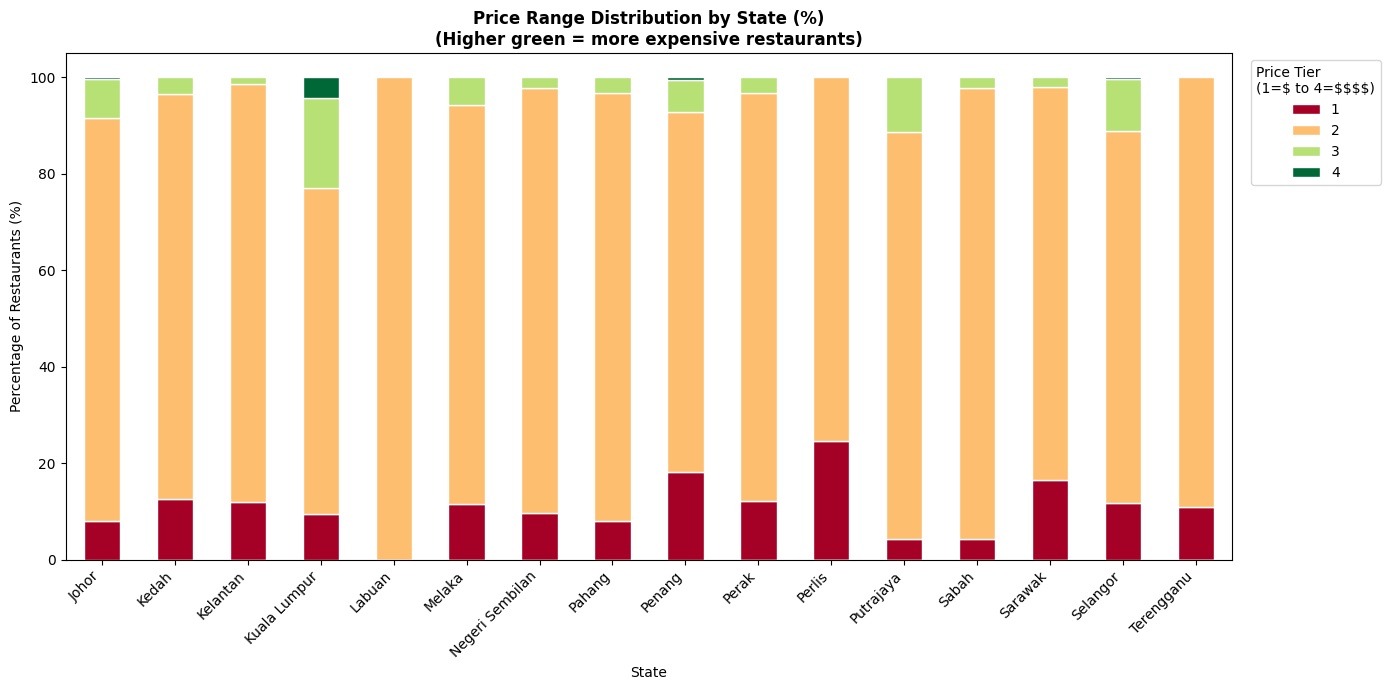


CHI-SQUARE TEST OF INDEPENDENCE
Chi² statistic:  246.2363
Degrees of freedom: 45
p-value:         0.0000

Assumption check:
  Cells with expected count < 5: 22/64 (34.4%)
  ⚠️  WARNING: >20% of cells have expected count < 5.
     Results should be interpreted with caution.

✅ SIGNIFICANT (p ≤ 0.05)
→ Price range IS significantly associated with state.
→ Expensive restaurants do NOT distribute randomly across Malaysia.

Effect Size — Cramér's V: 0.1776
  Interpretation: Weak association


In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

# ── Prepare data ──────────────────────────────────────────────────────────────
# Use restaurant-level data (one row per restaurant, deduplicated)
chi_df = not_null_restaurant[['state', 'priceRange']].dropna().copy()
chi_df['priceRange'] = chi_df['priceRange'].astype(int)
print(f"Restaurants included: {len(chi_df):,}")
print(f"States: {chi_df['state'].nunique()}")
print(f"Price tiers: {sorted(chi_df['priceRange'].unique())}")

# ── 1. Contingency Table ──────────────────────────────────────────────────────
contingency = pd.crosstab(chi_df['state'], chi_df['priceRange'])
print(f"\nContingency Table (rows=state, cols=price tier):")
print(contingency)

# ── 2. Visualise: Stacked % Bar Chart ────────────────────────────────────────
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
contingency_pct.plot(
    kind='bar', stacked=True, ax=ax,
    colormap='RdYlGn',
    edgecolor='white'
)
ax.set_title('Price Range Distribution by State (%)\n(Higher green = more expensive restaurants)', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Percentage of Restaurants (%)')
ax.legend(title='Price Tier\n(1=$ to 4=$$$$)', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── 3. Chi-Square Test ────────────────────────────────────────────────────────
chi2, p_chi, dof, expected = chi2_contingency(contingency)

# Check assumption: % of cells with expected count < 5
cells_below_5 = (expected < 5).sum()
total_cells = expected.size
pct_below_5 = (cells_below_5 / total_cells) * 100

print(f"\n{'='*60}")
print("CHI-SQUARE TEST OF INDEPENDENCE")
print(f"{'='*60}")
print(f"Chi² statistic:  {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value:         {p_chi:.4f}")
print(f"\nAssumption check:")
print(f"  Cells with expected count < 5: {cells_below_5}/{total_cells} ({pct_below_5:.1f}%)")
if pct_below_5 > 20:
    print("  ⚠️  WARNING: >20% of cells have expected count < 5.")
    print("     Results should be interpreted with caution.")
else:
    print("  ✅ Assumption met (<20% of cells below expected count of 5)")

print()
if p_chi < 0.05:
    print("✅ SIGNIFICANT (p ≤ 0.05)")
    print("→ Price range IS significantly associated with state.")
    print("→ Expensive restaurants do NOT distribute randomly across Malaysia.")
else:
    print("❌ NOT significant (p > 0.05)")
    print("→ No significant geographic clustering of expensive restaurants.")

# ── 4. Effect Size: Cramér's V ────────────────────────────────────────────────
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nEffect Size — Cramér's V: {cramers_v:.4f}")
if cramers_v < 0.1:
    print("  Interpretation: Negligible association")
elif cramers_v < 0.3:
    print("  Interpretation: Weak association")
elif cramers_v < 0.5:
    print("  Interpretation: Moderate association")
else:
    print("  Interpretation: Strong association")


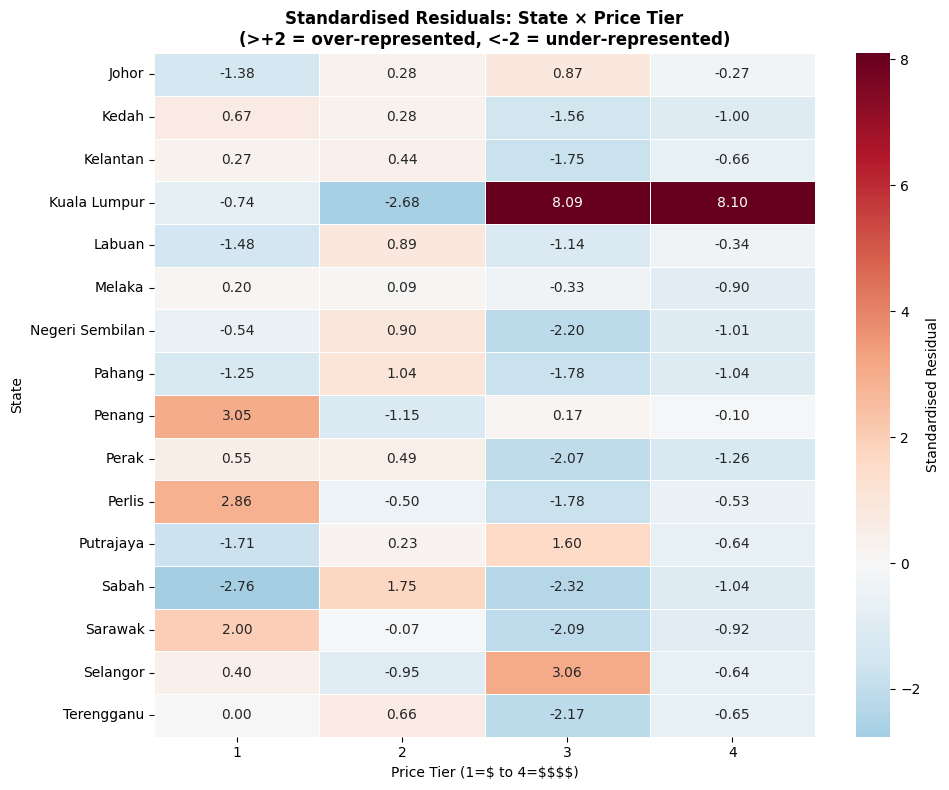

States with notably HIGH concentration of expensive restaurants (residual > +2):
  Kuala Lumpur — Tier 3: residual = 8.09 ✅
  Kuala Lumpur — Tier 4: residual = 8.10 ✅
  Selangor — Tier 3: residual = 3.06 ✅


In [68]:
# ── Heatmap: Standardised Residuals (which state-price combos are over/under-represented?) ──
# Standardised residual > +2 = significantly MORE than expected
# Standardised residual < -2 = significantly FEWER than expected

observed = contingency.values
std_residuals = (observed - expected) / np.sqrt(expected)
std_resid_df = pd.DataFrame(std_residuals, index=contingency.index, columns=contingency.columns)

plt.figure(figsize=(10, 8))
sns.heatmap(
    std_resid_df, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, linewidths=0.5,
    cbar_kws={'label': 'Standardised Residual'}
)
plt.title("Standardised Residuals: State × Price Tier\n(>+2 = over-represented, <-2 = under-represented)", fontweight='bold')
plt.xlabel('Price Tier (1=$ to 4=$$$$)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

print("States with notably HIGH concentration of expensive restaurants (residual > +2):")
for state in std_resid_df.index:
    for tier in std_resid_df.columns:
        val = std_resid_df.loc[state, tier]
        if val > 2 and tier >= 3:
            print(f"  {state} — Tier {tier}: residual = {val:.2f} ✅")
